In [6]:
# --- Core libraries ---
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import geopandas as gpd
from shapely.geometry import Point

# --- Scikit-learn: model training, preprocessing, CV, evaluation ---
from sklearn.model_selection import (
    GroupKFold,
    RandomizedSearchCV,
    cross_validate,
    train_test_split,
    GridSearchCV
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    balanced_accuracy_score,
    roc_auc_score,
    make_scorer,
    ConfusionMatrixDisplay
)
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import BallTree

# --- XGBoost ---
from xgboost import XGBRegressor, plot_tree, plot_importance
import xgboost  # Optional: useful for checking version

# --- Other ---
from haversine import haversine
import scipy.stats as stats
import gstools as gs #variogram modeling
from sklearn.metrics import pairwise_distances # for distance calculations
from scipy.cluster.hierarchy import linkage, dendrogram #for hierarchical clustering dendrogram

In [7]:
print("Current working directory:", os.getcwd())

#load in 
df_raw = pd.read_csv("../../../../data/finaldatasets/testdata/xgboost.csv")  # for variogram, etc.
df = df_raw.copy()  # working copy for feature engineering + model prep
print(list(df.columns))

Current working directory: /home/sebastian-dohne/Documents/FinalProject/code/analysis/kagglefeatureengineering/xgboost
['id', 'Data.ID', 'Location', 'State.Region.County.Province', 'Country', 'Continent', 'Latitude..N.S.', 'Longitude..E.W.', 'Conversion.for.latitude', 'Conversion.for.longitude', 'Location.source', 'Observation.period', 'Wheat.Type', 'Crop.variety', 'Tillage.type', 'Planting.date', 'Treatment', 'Treatment.type', 'Grain.yield..tons.ha.1.', 'Mean.annual.temperature..Â.C.', 'Water.regime', 'Mean.annual.precipitation..mm.', 'Irrigation..mm.', 'Soil.type', 'Sand', 'Silt', 'Clay', 'Soil.organic.carbon..g.C.kg.1.', 'Soil.pH', 'N.type', 'N.rate..kg.N.ha.1.', 'P.type', 'P.rate..kg.P.ha.1.', 'Plastic.film.mulching', 'Emissions..yes.no.', 'Pest.prescence....64', 'Pest.detected...65', 'Pest.severity.score.......66', 'rainfed_start_date', 'rainfed_end_date', 'irr_start_date', 'irr_end_date', 'start_date', 'end_date', 'Planting.date.1', 'Harvesting.date.1', 'Soil_N', 'pr_irrigated', 

/tmp/ipykernel_22976/668219514.py:4: DtypeWarning: Columns (6,7,13,14,15,16,17,20,22,23,29,31,33,34,35,36,37,44,45,70,74,75,76) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv("../../../../data/finaldatasets/testdata/xgboost.csv")  # for variogram, etc.


In [8]:
# data summary table
def summarize_column(col_data):
    numeric_data = pd.to_numeric(col_data, errors='coerce')
    is_numeric = numeric_data.notna().sum() > 0
    return {
        "dtype": col_data.dtype,
        "count": col_data.notna().sum(),
        "pct_complete": round(col_data.notna().mean() * 100, 1),
        "n_unique": col_data.nunique(dropna=True)
    }

# Build summary
summary_long = (
    pd.DataFrame([
        {"variable": col, **summarize_column(df[col])}
        for col in df.columns
    ])
    .sort_values(by="pct_complete", ascending=False)
    .reset_index(drop=True)
)

# Print in markdown table format
from tabulate import tabulate
print(tabulate(
    summary_long,
    headers="keys",
    tablefmt="github",
    showindex=False
))

| variable                                              | dtype   |   count |   pct_complete |   n_unique |
|-------------------------------------------------------|---------|---------|----------------|------------|
| id                                                    | int64   |   69932 |          100   |      69538 |
| Location.source                                       | object  |   69932 |          100   |          9 |
| year                                                  | int64   |   69932 |          100   |         17 |
| Elevation                                             | float64 |   69932 |          100   |        198 |
| Data.ID                                               | object  |   69932 |          100   |         52 |
| end_date                                              | int64   |   69932 |          100   |         10 |
| start_date                                            | int64   |   69932 |          100   |          7 |
| Grain.yield..tons.ha.1.   

In [9]:
# Define groups of columns to drop
LOCATION_COLS = [
    "id", "Data.ID", "Location", "State.Region.County.Province", "Country", "Continent",
    "Latitude..N.S.", "Longitude..E.W.",
    "Location.source", "Observation.period", "X", "Y", "unit_code"
]

# "Conversion.for.latitude", "Conversion.for.longitude"
HIGH_CARDINALITY_COLS = [
    "Treatment.type", "Emissions..yes.no.",
    "Irrigation..mm.", "Harvesting.date.1","Pest.severity.score.......66",
    "Agricultural_Use_–_Other_Pesticides_nes_(t)","Agricultural_Use_–_Rodenticides_(t)", 
    "irr_end_date", "end_date", "rainfed_end_date"
]


COLLINEAR_COLS = [
    "harvest_month", "harvest_date_clean", "harvest_week",
    "Planting.date", "Planting_Month", "Planting.date.1", "Planting_Week"
]

# These columns are used for testing purposes
TESTCOLUMNS = ["Crop.variety", "N.type"]

# Combine all columns to drop into a single set (to avoid duplicates)
COLUMNS_TO_DROP = set(LOCATION_COLS + HIGH_CARDINALITY_COLS + COLLINEAR_COLS + TESTCOLUMNS)

# Drop all listed columns if they exist in the DataFrame
df_cleaned = df.drop(columns=[col for col in COLUMNS_TO_DROP if col in df.columns])

# Optional: Review dropped and remaining columns
print("Original shape:", df.shape)
print("Shape after dropping:", df_cleaned.shape)
print("Dropped columns:", [col for col in COLUMNS_TO_DROP if col in df.columns])
print("Remaining columns:", df_cleaned.columns.tolist())

# Drop columns with less than 20% completeness
df_cleaned = df_cleaned.loc[:, df_cleaned.count() / len(df_cleaned) >= 0.2]

# Drop unnamed columns and rows with NaN in the target variable
df_cleaned = df_cleaned.loc[:, ~df_cleaned.columns.str.contains('^Unnamed')]
df_cleaned = df_cleaned.dropna(subset=["Grain.yield..tons.ha.1."])


Original shape: (69932, 95)
Shape after dropping: (69932, 66)
Dropped columns: ['Longitude..E.W.', 'Latitude..N.S.', 'irr_end_date', 'Planting_Month', 'Pest.severity.score.......66', 'Agricultural_Use_–_Other_Pesticides_nes_(t)', 'Crop.variety', 'Planting_Week', 'N.type', 'Harvesting.date.1', 'rainfed_end_date', 'Data.ID', 'Location', 'Continent', 'Observation.period', 'Agricultural_Use_–_Rodenticides_(t)', 'harvest_date_clean', 'Country', 'harvest_week', 'Treatment.type', 'end_date', 'Irrigation..mm.', 'id', 'harvest_month', 'State.Region.County.Province', 'Planting.date.1', 'Emissions..yes.no.', 'Planting.date', 'Location.source']
Remaining columns: ['Conversion.for.latitude', 'Conversion.for.longitude', 'Wheat.Type', 'Tillage.type', 'Treatment', 'Grain.yield..tons.ha.1.', 'Mean.annual.temperature..Â.C.', 'Water.regime', 'Mean.annual.precipitation..mm.', 'Soil.type', 'Sand', 'Silt', 'Clay', 'Soil.organic.carbon..g.C.kg.1.', 'Soil.pH', 'N.rate..kg.N.ha.1.', 'P.type', 'P.rate..kg.P.ha.

In [ ]:
# data summary table
def summarize_column(col_data):
    numeric_data = pd.to_numeric(col_data, errors='coerce')
    is_numeric = numeric_data.notna().sum() > 0
    return {
        "dtype": col_data.dtype,
        "count": col_data.notna().sum(),
        "pct_complete": round(col_data.notna().mean() * 100, 1),
        "n_unique": col_data.nunique(dropna=True)
    }

# Build summary
summary_long = (
    pd.DataFrame([
        {"variable": col, **summarize_column(df[col])}
        for col in df.columns
    ])
    .sort_values(by="pct_complete", ascending=False)
    .reset_index(drop=True)
)

# Print in markdown table format
from tabulate import tabulate
print(tabulate(
    summary_long,
    headers="keys",
    tablefmt="github",
    showindex=False
))

| variable                                              | dtype   |   count |   pct_complete |   n_unique |
|-------------------------------------------------------|---------|---------|----------------|------------|
| id                                                    | int64   |   69932 |          100   |      69538 |
| Location.source                                       | object  |   69932 |          100   |          9 |
| year                                                  | int64   |   69932 |          100   |         17 |
| Elevation                                             | float64 |   69932 |          100   |        198 |
| Data.ID                                               | object  |   69932 |          100   |         52 |
| end_date                                              | int64   |   69932 |          100   |         10 |
| start_date                                            | int64   |   69932 |          100   |          7 |
| Grain.yield..tons.ha.1.   

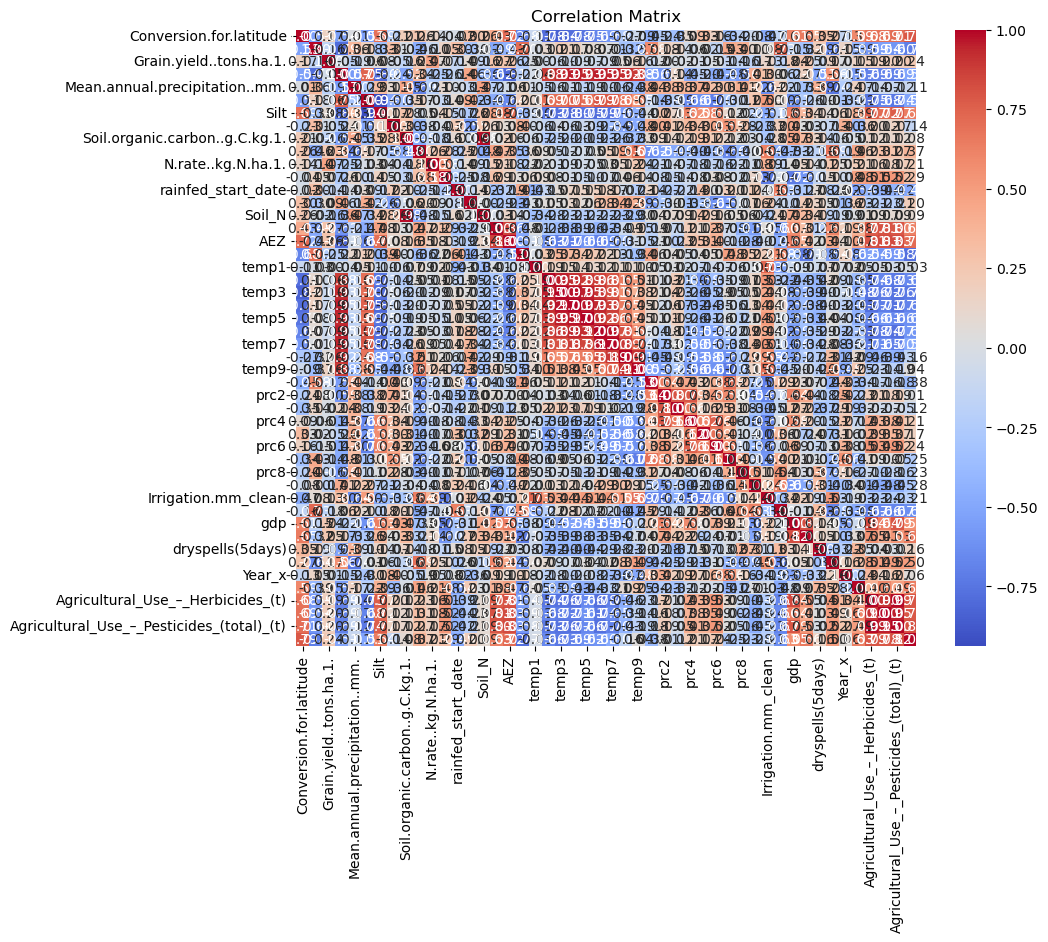

In [10]:
# Select only float columns for correlation
# Select only float columns except the target variable
float_cols = df_cleaned.select_dtypes(include=['float64', 'float32'])
corr_matrix = float_cols.corr(method='pearson')

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

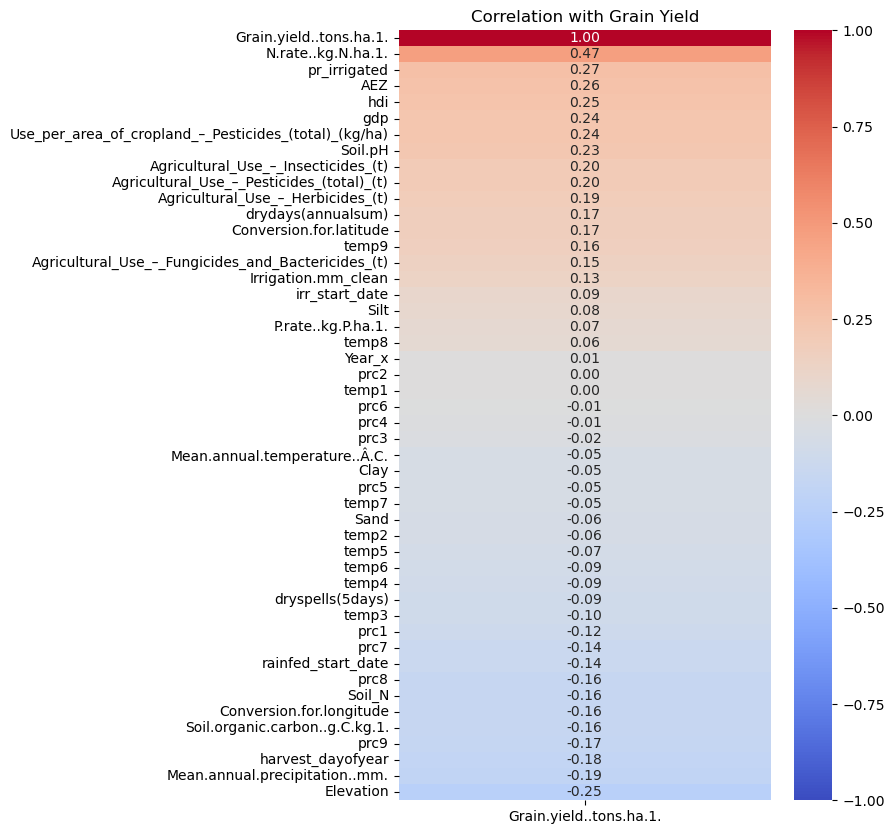

In [11]:
# Select only float columns (including 'Grain')
float_cols = df_cleaned.select_dtypes(include=['float64', 'float32'])

# Compute full correlation matrix
corr_matrix = float_cols.corr(method='pearson')

# Extract only correlations with 'Grain'
grain_corr = corr_matrix[['Grain.yield..tons.ha.1.']].sort_values(by='Grain.yield..tons.ha.1.', ascending=False)

# Plot
plt.figure(figsize=(6,10))
sns.heatmap(grain_corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation with Grain Yield")
plt.show()

/tmp/ipykernel_22976/3992205500.py:11: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linked = linkage(distance_matrix, method='ward')


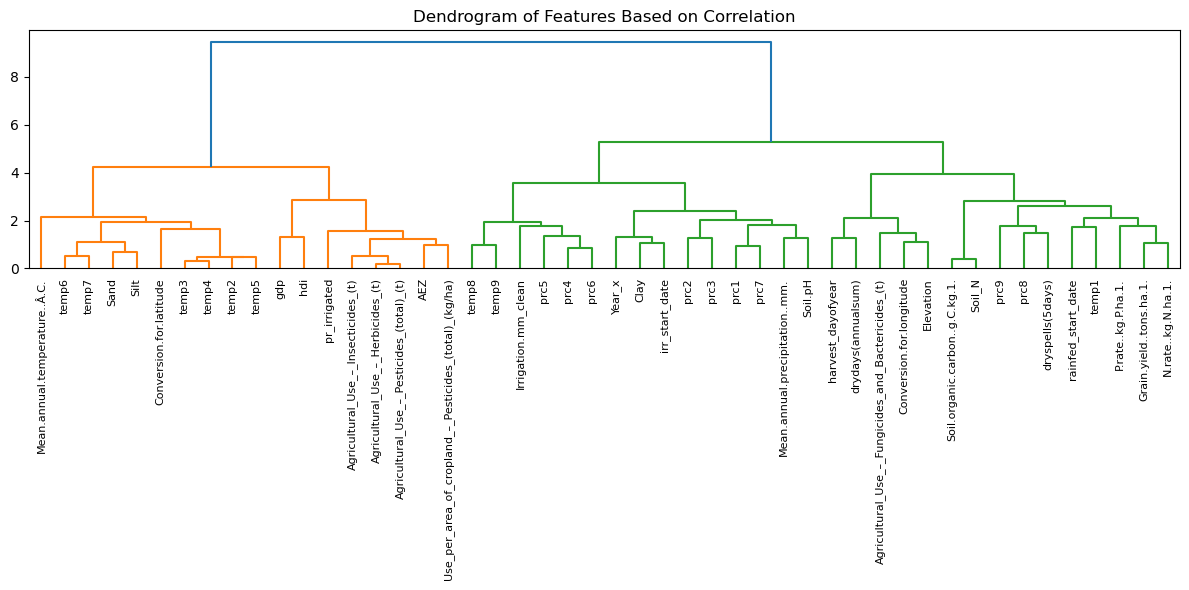

In [12]:
# Keep just the float columns
float_cols = df_cleaned.select_dtypes(include=['float64', 'float32'])

# Compute absolute correlation matrix
corr_matrix = float_cols.corr().abs()

# Convert correlation to distance
distance_matrix = 1 - corr_matrix

# Perform hierarchical clustering (linkage requires condensed distance matrix)
linked = linkage(distance_matrix, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linked, labels=distance_matrix.columns, leaf_rotation=90)
plt.title("Dendrogram of Features Based on Correlation")
plt.tight_layout()
plt.show()